In [34]:
import pandas as pd
import matplotlib.pyplot as plt

In [66]:
raw_df = pd.read_csv("cumulative_2026.03.09_14.43.47.csv", comment="#")
# storing candidates separately for testing at the end
df_candidates = raw_df[raw_df["koi_disposition"] == "CANDIDATE"]
df = raw_df[raw_df["koi_disposition"] != "CANDIDATE"]

# removing leakage - they contain the answer for the classifier already, as well as admin/meta info
df = df.drop(columns=["koi_score", "koi_pdisposition", "koi_fpflag_nt", "koi_fpflag_ss", 
                      "koi_fpflag_co", "koi_fpflag_ec", "koi_disp_prov", "koi_vet_stat", 
                      "koi_vet_date", "koi_comment"])
# keep for later but don't need in the df itself
df_misc = df[["kepid", "kepoi_name", "kepler_name"]]
df = df.drop(columns=["kepid", "kepoi_name", "kepler_name"])
# other non-useful data to drop
df = df.drop(columns=["koi_quarters", "koi_tce_plnt_num", "koi_tce_delivname", "ra", "dec"])
# more irrelavant data
df = df.drop(columns=[
    'koi_time0bk', 'koi_time0',
    'koi_eccen', 'koi_longp',
    'koi_fittype', 'koi_limbdark_mod', 'koi_trans_mod', 'koi_parm_prov', 'koi_sparprov',
    'koi_ldm_coeff1', 'koi_ldm_coeff2', 'koi_ldm_coeff3', 'koi_ldm_coeff4',
    'koi_datalink_dvr', 'koi_datalink_dvs',
    'koi_fwm_stat_sig', 'koi_fwm_sra', 'koi_fwm_sdec', 'koi_fwm_srao',
    'koi_fwm_sdeco', 'koi_fwm_prao', 'koi_fwm_pdeco',
    'koi_dicco_mra', 'koi_dicco_mdec', 'koi_dicco_msky',
    'koi_dikco_mra', 'koi_dikco_mdec', 'koi_dikco_msky',
    'koi_count',
    'koi_kepmag', 'koi_gmag', 'koi_rmag', 'koi_imag',
    'koi_zmag', 'koi_jmag', 'koi_hmag', 'koi_kmag'
])

# these 4 columns only have null values anyways
df = df.drop(columns=["koi_sage", "koi_ingress", "koi_model_chisq", "koi_model_dof"])


In [67]:
df.head()

,rowid,koi_disposition,koi_period,koi_impact,koi_duration,koi_depth,koi_ror,koi_srho,koi_prad,koi_sma,...,koi_max_sngle_ev,koi_max_mult_ev,koi_model_snr,koi_num_transits,koi_bin_oedp_sig,koi_steff,koi_slogg,koi_smet,koi_srad,koi_smass
0,1,CONFIRMED,9.488036,0.146,2.95750,615.8,0.022344,3.20796,2.26,0.0853,...,5.135849,28.470820,35.8,142.0,0.6864,5455.0,4.467,0.14,0.927,0.919
1,2,CONFIRMED,54.418383,0.586,4.50700,874.8,0.027954,3.02368,2.83,0.2734,...,7.027669,20.109507,25.8,25.0,0.0023,5455.0,4.467,0.14,0.927,0.919
3,4,FALSE POSITIVE,1.736952,1.276,2.40641,8079.2,0.387394,0.22080,33.46,0.0267,...,39.066550,541.895100,505.6,621.0,0.0000,5805.0,4.564,-0.52,0.791,0.836
4,5,CONFIRMED,2.525592,0.701,1.65450,603.3,0.024064,1.98635,2.75,0.0374,...,4.749945,33.191900,40.9,515.0,0.3090,6031.0,4.438,0.07,1.046,1.095
5,6,CONFIRMED,11.094321,0.538,4.59450,1517.5,0.036779,0.67324,3.90,0.0992,...,9.046456,55.204865,66.5,95.0,0.0975,6046.0,4.486,-0.08,0.972,1.053


In [61]:
# Significantly more false positives than confirmed, so I'll have to do some filtering later.
df['koi_disposition'].value_counts()

koi_disposition
FALSE POSITIVE    4839
CONFIRMED         2746
Name: count, dtype: int64

In [69]:
df.describe()

,rowid,koi_period,koi_impact,koi_duration,koi_depth,koi_ror,koi_srho,koi_prad,koi_sma,koi_incl,...,koi_max_sngle_ev,koi_max_mult_ev,koi_model_snr,koi_num_transits,koi_bin_oedp_sig,koi_steff,koi_slogg,koi_smet,koi_srad,koi_smass
count,7585.000000,7585.000000,7326.000000,7585.000000,7.326000e+03,7326.000000,7366.000000,7326.000000,7326.000000,7325.000000,...,6904.000000,6904.000000,7326.000000,6904.000000,6675.000000,7326.000000,7326.000000,7306.000000,7326.000000,7326.000000
mean,4562.428609,51.660971,0.756127,5.713065,2.952961e+04,0.293333,6.958481,104.169379,0.190266,81.227089,...,213.510645,1242.699160,318.594049,419.015353,0.387775,5715.973928,4.310837,-0.127553,1.752564,1.023282
std,2799.120819,111.838381,3.196379,6.826210,9.117009e+04,3.155387,48.264383,3180.483497,0.291215,16.391955,...,846.966472,4559.010980,881.096351,568.780061,0.524042,819.235213,0.437200,0.282215,6.279191,0.353275
min,1.000000,0.241843,0.000000,0.104600,8.000000e-01,0.001289,0.000040,0.080000,0.005900,2.290000,...,2.538761,7.105086,0.000000,0.000000,-1.000000,2661.000000,0.047000,-2.500000,0.116000,0.000000
25%,2104.000000,2.243041,0.227000,2.474300,1.826500e+02,0.013230,0.183103,1.500000,0.033400,82.050000,...,4.223582,12.903739,15.400000,46.000000,0.105900,5313.000000,4.218000,-0.260000,0.829000,0.843250
50%,4440.000000,8.073941,0.586000,3.836000,5.015000e+02,0.023843,0.791455,2.620000,0.075550,88.020000,...,6.222944,24.091312,30.500000,164.000000,0.467800,5774.000000,4.438000,-0.100000,1.000000,0.973000
75%,6945.000000,30.552897,0.917000,6.271000,2.319050e+03,0.197202,2.440615,24.185000,0.177475,89.640000,...,26.454360,122.105037,114.775000,549.000000,0.810350,6116.750000,4.543000,0.070000,1.346750,1.100000
max,9564.000000,1071.232624,100.806000,138.540000,1.541400e+06,99.870651,980.854190,200346.000000,2.152500,90.000000,...,22982.162000,120049.680000,9054.700000,2664.000000,1.000000,15896.000000,5.283000,0.560000,229.908000,3.735000


<Axes: ylabel='Frequency'>

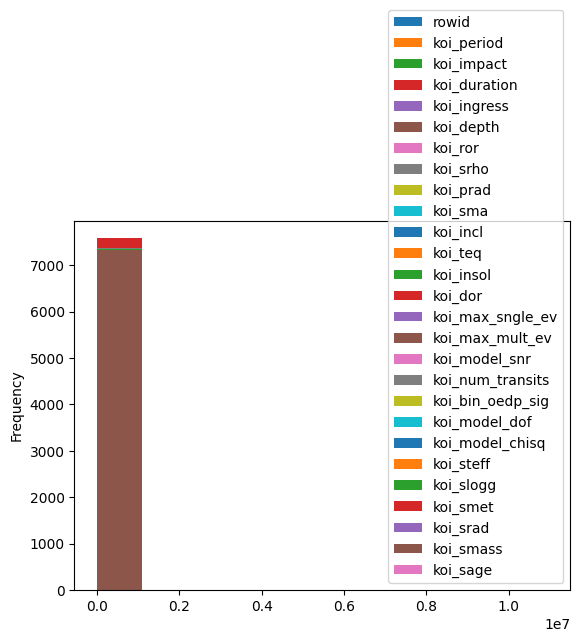

In [64]:
df.plot.hist()

In [68]:
df.isnull().sum().sort_values(ascending=False)

koi_bin_oedp_sig    910
koi_num_transits    681
koi_max_mult_ev     681
koi_max_sngle_ev    681
koi_smet            279
koi_incl            260
koi_model_snr       259
koi_dor             259
koi_steff           259
koi_teq             259
koi_smass           259
koi_prad            259
koi_slogg           259
koi_ror             259
koi_depth           259
koi_impact          259
koi_srad            259
koi_sma             259
koi_insol           219
koi_srho            219
koi_disposition       0
koi_duration          0
koi_period            0
rowid                 0
dtype: int64

In [54]:
len(df)

7585